In [21]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, TextLoader
from pathlib import Path
from tqdm import tqdm
LLM_MODEL = os.getenv("MODEL_LLM")
EMB_MODEL = os.getenv("MODEL_EMBEDDING")
os.environ.get("OPENAI_API_KEY")
DOCS_DIR = 'exports'
PERSIST_DIR = 'vector-store'
embeddings = OpenAIEmbeddings(model=EMB_MODEL)

In [22]:
from langchain_core.vectorstores import InMemoryVectorStore
vector_store = Chroma(
        collection_name="collection_test",
        embedding_function=embeddings,
        persist_directory=PERSIST_DIR,
    )

## Version avec site web on en récupère que les class post-title", "post-header", "post-content

In [23]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.2)

In [26]:
def load_docs(folder):
    paths = list(Path(folder).rglob("*"))
    docs = []
    print("voici la liste des documents")
    for p in tqdm(paths, desc="Load files"):
        print(p)
        try:
            if p.suffix.lower() == ".pdf":
                docs.extend(PyPDFLoader(str(p)).load())
            elif p.suffix.lower() == ".docx":
                docs.extend(Docx2txtLoader(str(p)).load())
            elif p.suffix.lower() in {".txt", ".md"}:
                docs.extend(TextLoader(str(p), encoding="utf-8").load())
        except Exception as e:
            print(f"Erreur lors du chargement de {p.name}: {e}")
    return docs

## Loading Documents

In [27]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

raw_docs = load_docs(DOCS_DIR)
splitter = RecursiveCharacterTextSplitter(
        chunk_size=800, chunk_overlap=120, separators=["\n\n", "\n", ". ", " "]
    )
all_splits = splitter.split_documents(raw_docs)
#utilisation de la version web

print(f"Split blog post into {len(all_splits)} sub-documents.")

voici la liste des documents


Load files:   0%|          | 0/100 [00:00<?, ?it/s]

exports/page-122.pdf


Load files:   2%|▏         | 2/100 [00:00<00:26,  3.76it/s]

exports/page-17.pdf
exports/page-16.pdf


...

exports/page-33.pdf
Erreur lors du chargement de page-33.pdf: Invalid Elementary Object starting with b'\x00' @299: b's\x00e\x00n\x00t\x00a\x00t\x00i\x00o\x00n\x00 )\x00 -451\x00 (\x00d\x00e\x00 )\x00 -451\x00 (\x00d\x00i\x00f\x00f\x00\xe9\x00r\x00e\x00n\x00t\x00s\x00 )\x00 -451\x00 (\x00w\x00'
exports/page-32.pdf
Erreur lors du chargement de page-32.pdf: Invalid Elementary Object starting with b'\x00' @934: b'(\x00F\x00i\x00r\x00e\x00b\x00a\x00s\x00e\x00 )\x00 -75\x00 (\x00e\x00s\x00t\x00 )\x00 -75\x00 (\x00u\x00t\x00i\x00l\x00i\x00s\x00\xe9\x00 )\x00 -75\x00 (\x00d\x00a\x00n\x00s\x00 '
exports/page-26.pdf


Load files:  98%|█████████▊| 98/100 [00:53<00:00,  2.42it/s]

exports/page-113.pdf
exports/page-107.pdf


Load files: 100%|██████████| 100/100 [00:53<00:00,  1.85it/s]

Split blog post into 461 sub-documents.


In [28]:
document_ids = vector_store.add_documents(documents=all_splits)

print(document_ids[:3])

['7e6ae51d-973f-46d8-a5a0-51bfae866f48', 'e60890e7-77b0-407e-aa6a-49d5dd02d1eb', '77563318-dc00-402d-9ca7-cd1eda8faa6d']


In [30]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question}\n"
    "Context: {context}\n"
    "Answer:"
)

In [37]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

In [38]:
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [39]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

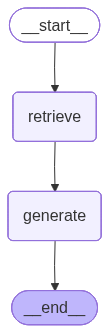

In [34]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
from langchain_community.callbacks.manager import get_openai_callback

with get_openai_callback() as cb:
    result = graph.invoke({"question": "Comment lire les logs d'un container docker ?"})
    print(f"Tokens d'entrée : {cb.prompt_tokens}")
    print(f"Tokens de sortie : {cb.completion_tokens}")
    print(f"Coût total : ${cb.total_cost:.6f}")

print(f"\nContext: {result['context']}\n")
print(f"Answer: {result['answer']}")

Tokens d'entrée : 695
Tokens de sortie : 582
Coût total : $0.000268

Context: [Document(id='7c3b93e3-61f1-4802-9f19-6bfb0a6020e0', metadata={'source': 'exports/page-9.pdf', 'creator': 'PyPDF', 'total_pages': 2, 'producer': 'dompdf 2.0.3 + CPDF', 'moddate': '2026-03-02T14:04:09+00:00', 'page': 1, 'title': 'Les commandes Docker', 'creationdate': '2026-03-02T14:04:09+00:00', 'page_label': '2'}, page_content="rm -f Supprimes un container de force\nmême s'il est encore actif\ndocker rm -f example\nrmi Supprimes une image docker rmi example\nexec Permet d'executer une commande\ndans un container actif\ndocker exec example\ninspect Permet de voir le détail complet d'un\ncontainer ou d'une image\ndocker inspect example\ncp Permet de copier des fichiers /\ndossiers d'une source vers une\ndestination\ndocker cp Download/test.txt\nabcd:/home\nattach {idContainer} Consulter l'ensemble des logs d'un\ncontainer (plus complet que la\ncommande logs)\ndocker attach 8181a222a73e\nvolume ls Permet de lis